In [1]:
import dagshub
dagshub.init(repo_owner='MohammedTawfikEldeeb', repo_name='telcom-churn', mlflow=True)

Accessing as MohammedTawfikEldeeb

Initialized MLflow to track repo "MohammedTawfikEldeeb/telcom-churn"

Repository MohammedTawfikEldeeb/telcom-churn initialized!

In [2]:
import mlflow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
# split the dataset
from sklearn.model_selection import train_test_split


# preprossing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , LabelEncoder , OrdinalEncoder
from sklearn.pipeline import Pipeline , FeatureUnion
from sklearn_features.transformers import DataFrameSelector
from datasist.structdata import detect_outliers
from sklearn.model_selection import cross_val_score, cross_val_predict
from imblearn.over_sampling import SMOTE,RandomOverSampler, ADASYN

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , classification_report , confusion_matrix

In [4]:
df = pd.read_csv('data/data_processed.csv')
df.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,customer_service_calls,churn,total_charge,total_minutes,total_calls
0,128,0,1,25,1,False,75.56,717.2,303
1,107,0,1,26,1,False,59.24,625.2,332
2,137,0,0,0,0,False,62.29,539.4,333
3,84,1,0,0,2,False,66.80,564.8,255
4,75,1,0,0,3,False,52.09,512.0,359


🏃 View run RandomForest_RandomOverSampler at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/a8c7589ef49545d593b2a38811169937
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
RandomOverSampler -> Accuracy: 0.9349 | Precision: 0.8079 | Recall: 0.7219 | F1: 0.7625
🏃 View run RandomForest_ADASYN at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0/runs/5ddaa4951d2f4d3fabebbc1ba081edad
🧪 View experiment at: https://dagshub.com/MohammedTawfikEldeeb/telcom-churn.mlflow/#/experiments/0
ADASYN -> Accuracy: 0.9126 | Precision: 0.6667 | Recall: 0.7929 | F1: 0.7243


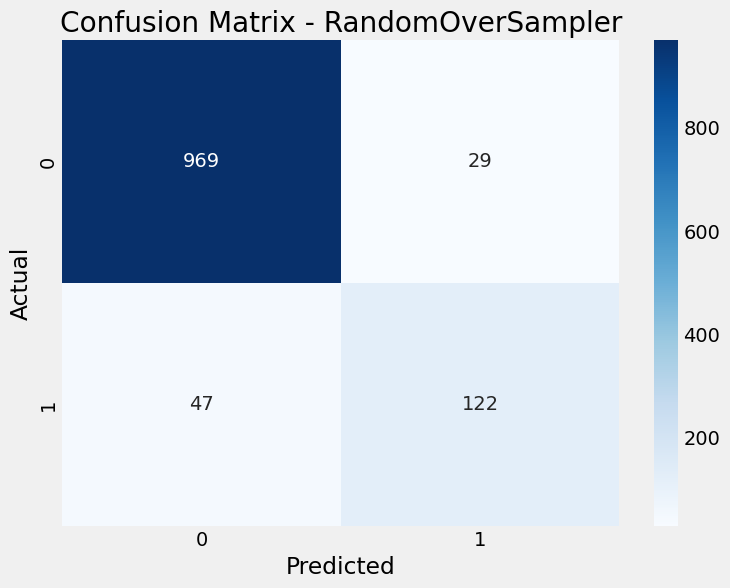

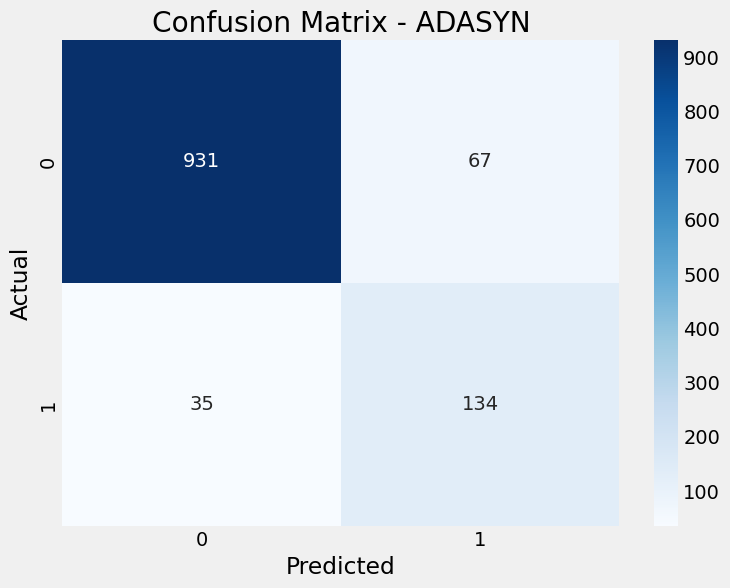

In [6]:
x = df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.35, random_state=42, stratify=y, shuffle=True
)

# ----------- Scale features -----------
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# ----------- Samplers to compare -----------
samplers = {
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

for sampler_name, sampler in samplers.items():
    # ----------- Resample train only -----------
    x_train_resampled, y_train_resampled = sampler.fit_resample(x_train_scaled, y_train)

    # ----------- MLflow Run -----------
    with mlflow.start_run():
        mlflow.set_tag("mlflow.runName", f"RandomForest_{sampler_name}")
        mlflow.set_tag("experiment_type", "sampling_comparison")
        mlflow.set_tag("model_type", "RandomForestClassifier")
        mlflow.log_param("sampling_method", sampler_name)
        mlflow.log_param("n_estimators", 200)
        mlflow.log_param("max_depth", 15)

        # ----------- Model -----------
        model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
        model.fit(x_train_resampled, y_train_resampled)
        y_pred = model.predict(x_test_scaled)

        # ----------- Metrics -----------
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)

        # ----------- Classification Report -----------
        classification_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # ----------- Confusion Matrix -----------
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - {sampler_name}")
        plt.savefig(f"confusion_matrix_{sampler_name}.png")
        mlflow.log_artifact(f"confusion_matrix_{sampler_name}.png")

        # ----------- Dataset Snapshot -----------
        df.to_csv(f"dataset_{sampler_name}.csv", index=False)
        mlflow.log_artifact(f"dataset_{sampler_name}.csv")

    print(f"{sampler_name} -> Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")